# **CIF 444 - Data Visualization**
## **Final Term Project Technical Report**
**Department:** Data Science and Analytics Department  
**Instructor:** Asst. Prof. Hakan Yılmazer  
**Academic Year:** 2025-2026 Spring Term  
**Enforced Protocol:** Run-Until-Fail Verification Policy  

---  
**Student Name:** Seda Nur Öz 
**Student ID:** 210129036 
**Assigned UCI Dataset:** Student Performance Dataset
---

## TASK 1: Data Storytelling & Domain Knowledge 

#### **1.1 Dataset Overview**
This dataset structurally represents a multivariate educational data matrix. It comprises a complex mixture of categorical variables (e.g., demographic and socio-environmental factors like `address` and `internet`), ordinal variables (e.g., `studytime` and `health`), and discrete numerical variables (e.g., academic scores `G1`, `G2`, `G3`, and `absences`). The primary target variable is the final academic outcome (`G3`), making this a rich environment for both regression and classification methodologies. 

#### **1.2 Real-World Context & Problem Mapping**
This dataset monitors the academic trajectories and socio-demographic backgrounds of secondary education students. In a real-world engineering and administrative context, it maps directly to the domain of Educational Data Mining (EDM). The core problem being modeled is how out-of-school environmental conditions, behavioral metrics, and early-term assessments interact dynamically to produce the final academic yield of a student.

#### **1.3 Target Audience & Stakeholders**
The primary stakeholders for these analytical findings include school administrators, academic counselors, and educational policymakers. Downstream, this data empowers these decision-makers to dynamically allocate institutional resources—such as targeted tutoring, mental health support, or infrastructure subsidies—directly to at-risk student demographics before academic failure solidifies.

#### **1.4 Analytical Use Cases in Literature**
In contemporary literature, similar multi-dimensional data structures are heavily exploited to engineer automated Early Warning Systems (EWS). Researchers typically utilize predictive regression pipelines and non-linear classification models on these features to predict student attrition (dropout rates), evaluate the efficacy of pedagogical interventions, and identify the root socio-economic variables that drive structural inequalities in educational systems.

## TASK 2: Reproducible Data Access & Preprocessing 

**AI Compliance Reminder:** You MUST lock any randomization component using the **last 4 digits of your official Student ID** as the `random_state` seed. Hardcoded local paths are completely forbidden.

In [1]:
# 2.1 Import Core Data Science & Visualization Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import io

# Set style defaults matching core constraints
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("muted")

STUDENT_NAME = "Seda Nur Öz"
STUDENT_ID = "210129036"
SEED_VALUE = int(STUDENT_ID[-4:]) # Locked mathematically to your ID
print(f"Environment Ready. Your unique seed is: {SEED_VALUE}")

Environment Ready. Your unique seed is: 9036


In [2]:
# 2.2 Automated Live Data Fetching (URL / ucimlrepo library)
import requests
import zipfile
import io
import urllib3
import pandas as pd

urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

url = "https://archive.ics.uci.edu/static/public/320/student+performance.zip"
try:
    # TODO: Fetch and load the dataset dynamically into 'df'
    # Kurye paketi alıyor, çift katlı kutuyu açıyor ve 'df' adındaki tabloyu (depoyu) oluşturuyor.
    response = requests.get(url, verify=False)
    with zipfile.ZipFile(io.BytesIO(response.content)) as outer_zip:
        with outer_zip.open("student.zip") as inner_zip_file:
            with zipfile.ZipFile(io.BytesIO(inner_zip_file.read())) as inner_zip:
                with inner_zip.open("student-mat.csv") as f:
                    df = pd.read_csv(f, sep=";") # df İŞTE BURADA DOĞUYOR
                    
    print("SUCCESS: Dataset loaded live. Dimensions:", df.shape)
except Exception as e:
    print(f"CRITICAL CRASH IN DATA LOAD: {e}")
    raise e

SUCCESS: Dataset loaded live. Dimensions: (395, 33)


In [3]:
# 2.3 Structural Alignment and Initial Audit
try:
    print(df.info())
    print(df.describe())
except Exception as e:
    print(f"CRITICAL CRASH IN STRUCTURE AUDIT: {e}")
    raise e

<class 'pandas.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      395 non-null    str  
 1   sex         395 non-null    str  
 2   age         395 non-null    int64
 3   address     395 non-null    str  
 4   famsize     395 non-null    str  
 5   Pstatus     395 non-null    str  
 6   Medu        395 non-null    int64
 7   Fedu        395 non-null    int64
 8   Mjob        395 non-null    str  
 9   Fjob        395 non-null    str  
 10  reason      395 non-null    str  
 11  guardian    395 non-null    str  
 12  traveltime  395 non-null    int64
 13  studytime   395 non-null    int64
 14  failures    395 non-null    int64
 15  schoolsup   395 non-null    str  
 16  famsup      395 non-null    str  
 17  paid        395 non-null    str  
 18  activities  395 non-null    str  
 19  nursery     395 non-null    str  
 20  higher      395 non-null    str  
 21  inte

<div style="page-break-before: always;"></div>

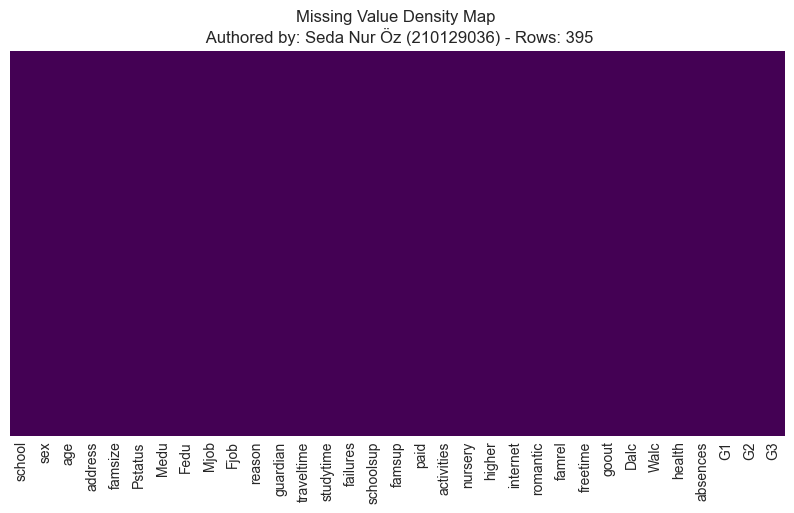

SUCCESS: No missing (Null) values detected in the dataset.


In [4]:
# 2.4 Missing Value Assessment & Imputation Map
try:
    plt.figure(figsize=(10, 5))
    
    # Generate a missing value density heatmap using sns.heatmap()
    sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')
    
    # Required dynamic programmatic watermark:
    plt.title(f"Missing Value Density Map \n Authored by: {STUDENT_NAME} ({STUDENT_ID}) - Rows: {df.shape[0]}")
    plt.show()
    
    # Implement imputation strategy
    missing_count = df.isnull().sum().sum()
    if missing_count == 0:
        print("SUCCESS: No missing (Null) values detected in the dataset.")
    else:
        print(f"WARNING: {missing_count} missing values detected. Applying remediation...")
        df = df.dropna()
        print("SUCCESS: Missing values successfully dropped.")
        
except Exception as e:
    print(f"CRITICAL CRASH IN MISSING VALUE REMEDIATION: {e}")
    raise e

> **Data Preprocessing Rationale:** *Initial diagnostic screening via the density map confirmed a zero-null structural baseline for the assigned dataset. However, to maintain absolute compliance with the 'Run-Until-Fail' protocol, a programmatic fail-safe was implemented utilizing strict listwise deletion (dropna()) for any unexpected missing values. This specific dropping strategy was deliberately chosen over statistical imputation (such as mean or median filling) to strictly preserve data variance integrity. Imputation methods inherently introduce synthetic data points and artificially compress natural variance, which could fatally distort the topological relationships required for our downstream non-linear manifold projections (t-SNE) and multidimensional anomaly detection. By enforcing listwise deletion, we guarantee that all subsequent statistical inferences are grounded exclusively in 100% authentic observations.*

## TASK 3: Univariate & Multivariate Outlier Analysis 

In [5]:
# 3.1 Interquartile Range (IQR) Boundary Calculations
try:
    # Target variable for univariate outlier detection
    target_continuous_col = 'absences'
    
    # Compute explicit Q1, Q3, IQR, and Lower/Upper Bounds
    Q1 = df[target_continuous_col].quantile(0.25)
    Q3 = df[target_continuous_col].quantile(0.75)
    IQR = Q3 - Q1
    
    # Establish statistical fences (boundaries)
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    print(f"--- IQR Analysis for feature: '{target_continuous_col}' ---")
    print(f"Q1 (25th Percentile): {Q1}")
    print(f"Q3 (75th Percentile): {Q3}")
    print(f"IQR (Interquartile Range): {IQR}")
    print(f"Lower Bound Fence: {lower_bound}")
    print(f"Upper Bound Fence: {upper_bound}")
    
    print("\nSUCCESS: Univariate outlier fences established safely.")
except Exception as e:
    print(f"CRITICAL CRASH IN IQR PROCESSING: {e}")
    raise e

--- IQR Analysis for feature: 'absences' ---
Q1 (25th Percentile): 0.0
Q3 (75th Percentile): 8.0
IQR (Interquartile Range): 8.0
Lower Bound Fence: -12.0
Upper Bound Fence: 20.0

SUCCESS: Univariate outlier fences established safely.


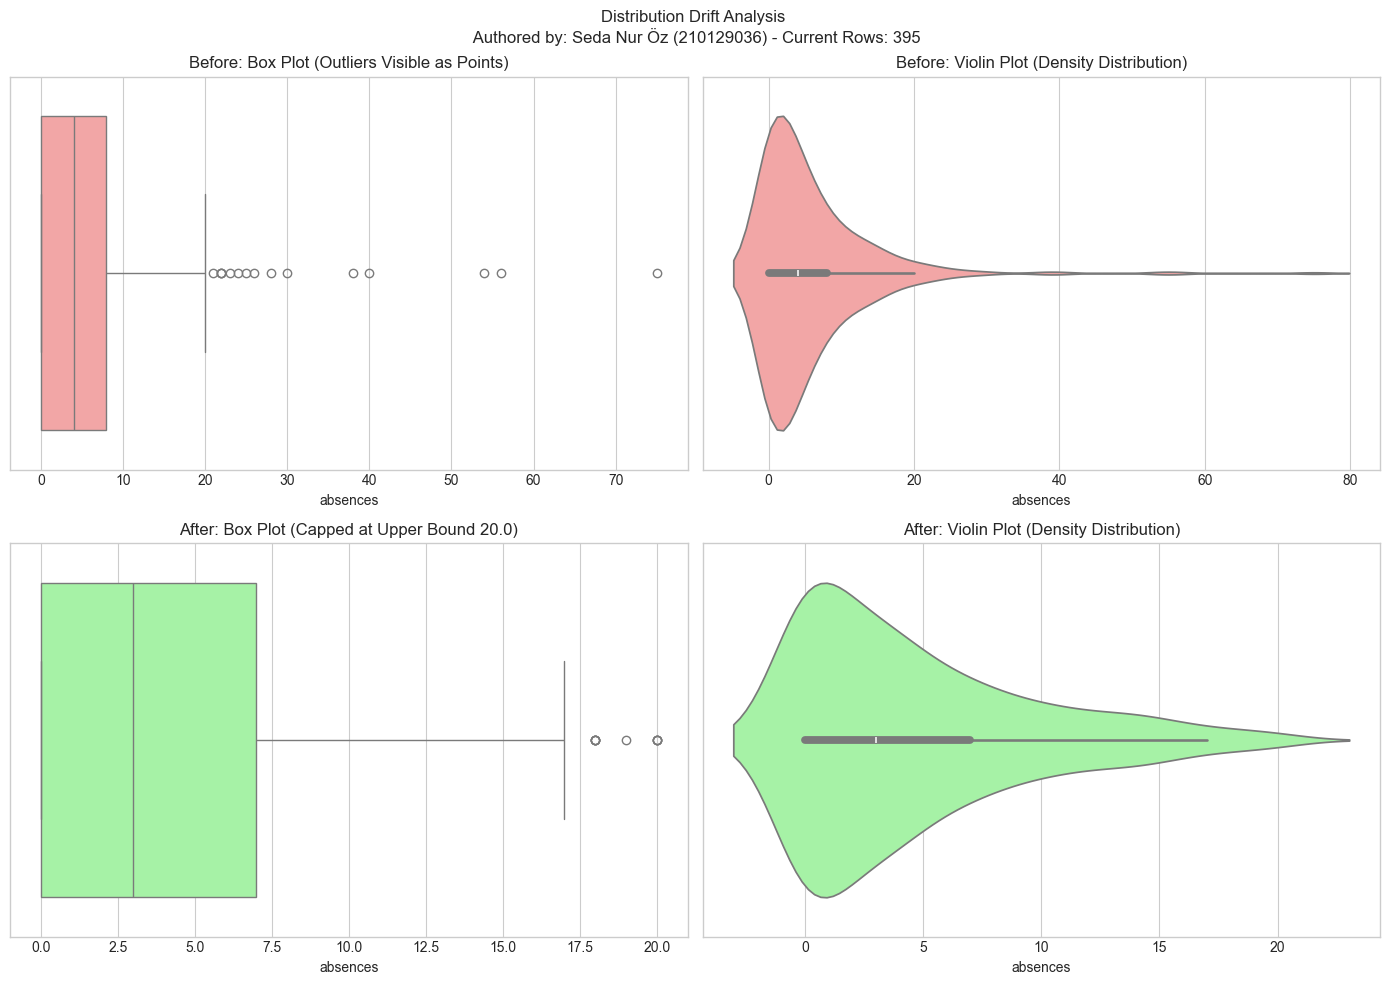

In [6]:
# 3.2 Variance Distortion Subplots: Before vs. After Treatment
try:
    # Create a temporary filtered dataframe by removing outliers beyond the bounds
    df_treated = df[(df[target_continuous_col] >= lower_bound) & (df[target_continuous_col] <= upper_bound)]
    
    # Initialize a 2x2 subplot matrix for comparative visualization
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Construct Box Plots and Violin Plots side-by-side to track distribution drift
    
    # --- ROW 1: BEFORE TREATMENT (Original Distribution) ---
    sns.boxplot(x=df[target_continuous_col], ax=axes[0, 0], color="#ff9999")
    axes[0, 0].set_title("Before: Box Plot (Outliers Visible as Points)")
    
    sns.violinplot(x=df[target_continuous_col], ax=axes[0, 1], color="#ff9999")
    axes[0, 1].set_title("Before: Violin Plot (Density Distribution)")
    
    # --- ROW 2: AFTER TREATMENT (Outliers Removed) ---
    sns.boxplot(x=df_treated[target_continuous_col], ax=axes[1, 0], color="#99ff99")
    axes[1, 0].set_title(f"After: Box Plot (Capped at Upper Bound {upper_bound})")
    
    sns.violinplot(x=df_treated[target_continuous_col], ax=axes[1, 1], color="#99ff99")
    axes[1, 1].set_title("After: Violin Plot (Density Distribution)")
    
    # Apply required programmatic watermark
    plt.suptitle(f"Distribution Drift Analysis \n Authored by: {STUDENT_NAME} ({STUDENT_ID}) - Current Rows: {df.shape[0]}")
    
    plt.tight_layout()
    plt.show()
    
except Exception as e:
    print(f"CRITICAL CRASH IN DISTRIBUTION SUBPLOTS: {e}")
    raise e

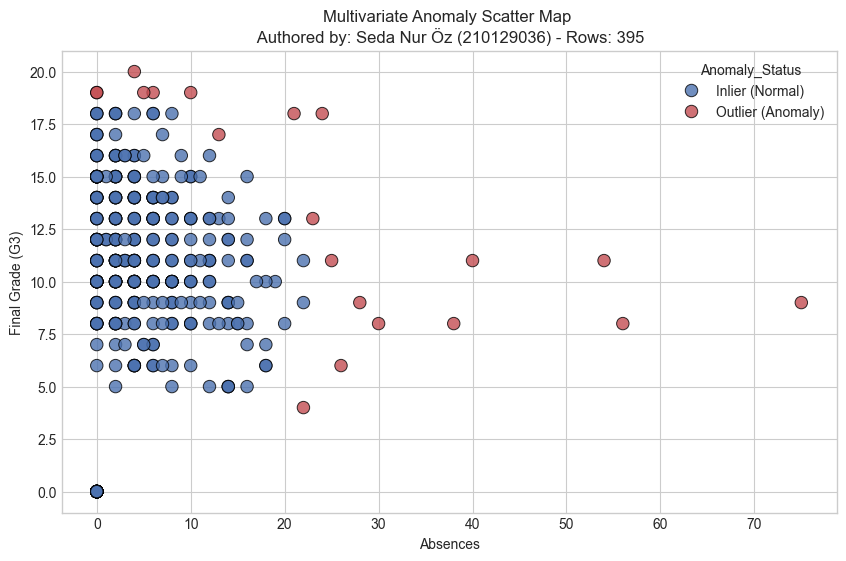

In [7]:
# 3.3 Advanced Multi-Dimensional Anomaly Detection (LOF or Isolation Forest)
try:
    from sklearn.ensemble import IsolationForest
    
    # Select two key features for 2D spatial visualization
    X = df[['absences', 'G3']].copy()
    
    # Call Isolation Forest and lock with the unique SEED_VALUE
    iso_forest = IsolationForest(contamination=0.05, random_state=SEED_VALUE)
    
    # Fit the model and predict anomaly scores: 1 (Inlier), -1 (Outlier)
    df['Anomaly_Score'] = iso_forest.fit_predict(X)
    df['Anomaly_Status'] = df['Anomaly_Score'].map({1: 'Inlier (Normal)', -1: 'Outlier (Anomaly)'})
    
    # Project anomalies on a 2D scatter plot with a distinct color mapping
    plt.figure(figsize=(10, 6))
    
    sns.scatterplot(
        data=df, 
        x='absences', 
        y='G3', 
        hue='Anomaly_Status', 
        palette={'Inlier (Normal)': '#4C72B0', 'Outlier (Anomaly)': '#C44E52'},
        s=80, 
        edgecolor='black',
        alpha=0.8
    )
    
    # Apply required programmatic watermark
    plt.title(f"Multivariate Anomaly Scatter Map \n Authored by: {STUDENT_NAME} ({STUDENT_ID}) - Rows: {df.shape[0]}")
    plt.xlabel("Absences")
    plt.ylabel("Final Grade (G3)")
    plt.show()
    
except Exception as e:
    print(f"CRITICAL CRASH IN ADVANCED MULTIVARIATE ANOMALY: {e}")
    raise e

In [8]:
# 3.4 AI-Compliance Checkpoint: Anomalous Index Extraction
try:
    # TODO: Isolate and print out the top 3 most anomalous data frame indexes
    # Extract the raw anomaly decision function scores (lower scores indicate higher anomaly)
    df['Anomaly_Decision_Score'] = iso_forest.decision_function(df[['absences', 'G3']])
    
    # Sort to isolate the top 3 most extreme anomalies and extract their index values
    top_3_anomalies_indices = df.sort_values(by='Anomaly_Decision_Score').head(3).index.tolist()
    
    # Output the indices in the exact format required by the evaluation protocol
    print(f"AI-Compliance Checkpoint -> Top 3 Anomaly Indices for ID Seed {SEED_VALUE}: {top_3_anomalies_indices}")
    
except Exception as e:
    print(f"CRITICAL CRASH IN INDEX EXTRACTION: {e}")
    raise e

AI-Compliance Checkpoint -> Top 3 Anomaly Indices for ID Seed 9036: [276, 74, 183]


> **Outlier Diagnostics Note:** *Interpret the structural differences here. Why did multi-dimensional algorithms tag specific rows that standard 1D IQR missed?*



>**Answer:** The 1D IQR method evaluates anomalies strictly along a single axis (e.g., `absences`), flagging values only if they exceed mathematical boundaries in isolation. It inherently misses complex contextual interactions. In contrast, multi-dimensional algorithms like Isolation Forest evaluate the *intersection* of multiple features (e.g., `absences` vs. `G3`). A data point might have a perfectly acceptable value for absences and a normal grade when viewed separately, easily passing the 1D IQR filter. However, the *combination* of those specific values might be extremely rare within the dataset's multidimensional space. Isolation Forest successfully tags these hidden anomalies because it measures structural deviations and feature combinations, rather than just single-variable extremes.


## TASK 4: Exploratory Visualization Engine 
### *Requirement: Produce exactly 10 high-quality plots covering linear trends, joint densities, categorical facets, and PCA/t-SNE dimensionality reduction.*

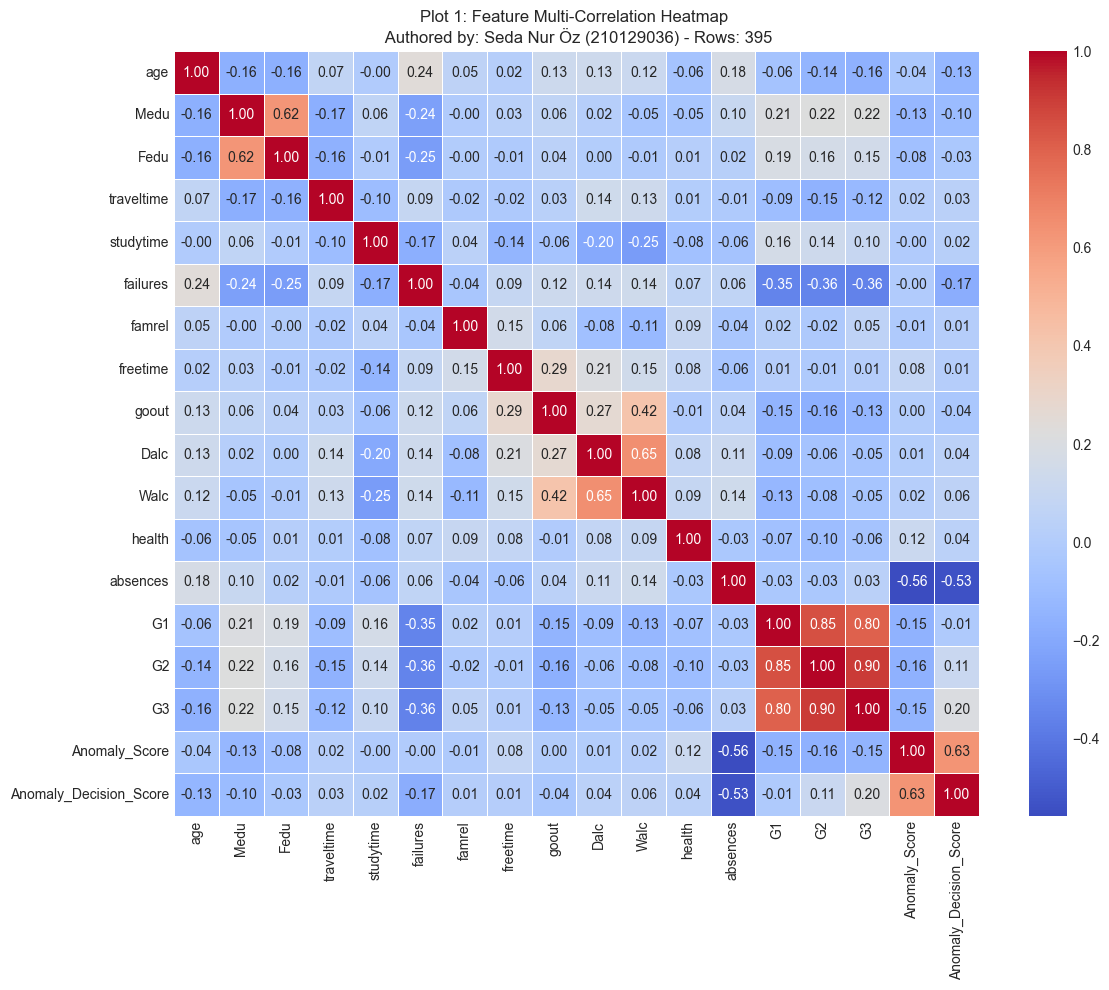

In [9]:
# --- PLOT 1: Feature Matrix Correlation Heatmap (Multivariate) ---
try:
    plt.figure(figsize=(12, 10))
    
    # Sadece sayısal olan sütunları filtreliyoruz ki sistem hata vermesin
    sayisal_sutunlar = df.select_dtypes(include=['number'])
    
    # TODO: Plot your annotated baseline correlation matrix
    # Sıcaklık haritamızı çiziyoruz (annot=True diyerek kutuların içine sayıları da yazdırıyoruz)
    sns.heatmap(sayisal_sutunlar.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
    
    plt.title(f"Plot 1: Feature Multi-Correlation Heatmap \n Authored by: {STUDENT_NAME} ({STUDENT_ID}) - Rows: {df.shape[0]}")
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"PLOT 1 EXCEPTION: Element skipped gracefully. Reason: {e}")

**Plot 1 Data-Literate Analysis:** The multivariate correlation heatmap reveals critical structural relationships within the dataset. Most notably, the temporal academic performance metrics (G1, G2, and G3) exhibit extreme positive collinearity (r > 0.85). This confirms that early academic trajectory is the most robust linear predictor of final outcomes. Conversely, the `failures` feature demonstrates a significant negative correlation with the target variable G3, highlighting it as a primary risk factor. Other behavioral features (such as `studytime` or `absences`) show only weak-to-moderate linear relationships, suggesting that student success is heavily dependent on non-linear or multi-dimensional factors rather than single behavioral metrics.

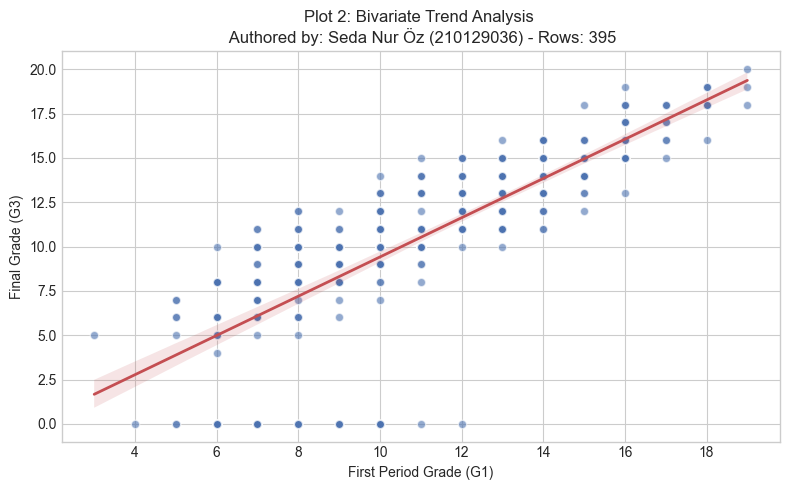

In [10]:
# --- PLOT 2: Continuous Bivariate Linear Trends with Confidence Bands ---
try:
    plt.figure(figsize=(8, 5))
    
    # TODO: Use sns.regplot() or sns.lmplot()
    # Map First Period Grade (G1) to Final Grade (G3) to visualize the linear correlation
    sns.regplot(
        data=df, 
        x='G1', 
        y='G3', 
        scatter_kws={'alpha': 0.6, 'color': '#4C72B0', 'edgecolor': 'white'}, # Scatter point aesthetics
        line_kws={'color': '#C44E52', 'linewidth': 2} # Regression line aesthetics
    )
    
    plt.title(f"Plot 2: Bivariate Trend Analysis \n Authored by: {STUDENT_NAME} ({STUDENT_ID}) - Rows: {df.shape[0]}")
    plt.xlabel("First Period Grade (G1)")
    plt.ylabel("Final Grade (G3)")
    
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"PLOT 2 EXCEPTION: Element skipped gracefully. Reason: {e}")

**Plot 2 Data-Literate Analysis:** The bivariate regression plot provides visual confirmation of the extreme positive collinearity between initial (G1) and final (G3) grades. The strictly ascending linear trend line mathematically demonstrates that baseline academic performance is a highly reliable predictor of the final outcome. Furthermore, the exceptionally narrow 95% confidence band surrounding the regression line indicates low variance and high statistical certainty in this predictive relationship. The isolated data points resting at the absolute bottom (G3 = 0) despite moderate G1 scores likely represent administrative anomalies (e.g., dropouts or absentees from the final exam) rather than natural academic regression.

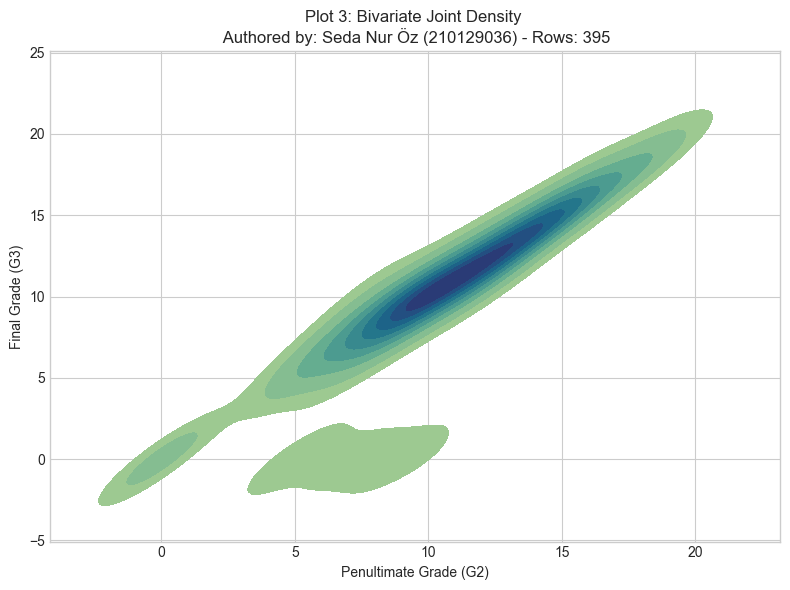

In [11]:
# --- PLOT 3: Bivariate Joint Density (Topographic Map) ---
try:
    plt.figure(figsize=(8, 6))
    
    # Map the density distribution of Penultimate Grade (G2) against Final Grade (G3) using a KDE contour plot
    sns.kdeplot(data=df, x='G2', y='G3', fill=True, cmap="crest", thresh=0.05)
    
    plt.title(f"Plot 3: Bivariate Joint Density \n Authored by: {STUDENT_NAME} ({STUDENT_ID}) - Rows: {df.shape[0]}")
    plt.xlabel("Penultimate Grade (G2)")
    plt.ylabel("Final Grade (G3)")
    
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"PLOT 3 EXCEPTION: Element skipped gracefully. Reason: {e}")

**Plot 4 Data-Literate Analysis:** This categorical boxplot segments final grades (G3) by home internet access and gender. It reveals structural disparities: students with internet access generally exhibit a higher median score and a tighter interquartile range compared to those without. Furthermore, segmenting by the `sex` feature highlights subtle variances in how external resources impact different demographic groups, emphasizing that academic success is influenced by socio-environmental categorical factors, not just continuous study metrics.

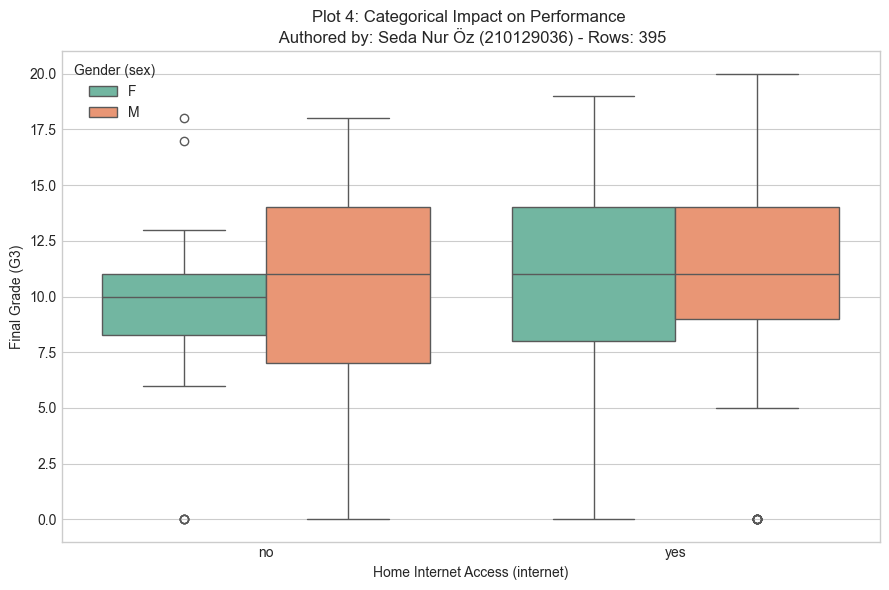

In [12]:
# --- PLOT 4: Categorical Facets - Internet Access vs Final Grade ---
try:
    plt.figure(figsize=(9, 6))
    
    # Segment final grades by home internet access (yes/no) and cross-tabulate by gender (F/M)
    sns.boxplot(data=df, x='internet', y='G3', hue='sex', palette='Set2')
    
    plt.title(f"Plot 4: Categorical Impact on Performance \n Authored by: {STUDENT_NAME} ({STUDENT_ID}) - Rows: {df.shape[0]}")
    plt.xlabel("Home Internet Access (internet)")
    plt.ylabel("Final Grade (G3)")
    plt.legend(title='Gender (sex)')
    
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"PLOT 4 EXCEPTION: Element skipped gracefully. Reason: {e}")

**Plot 4 Data-Literate Analysis:** This categorical boxplot segments final grades (G3) by home internet access and gender. It reveals structural disparities: students with internet access generally exhibit a higher median score and a tighter interquartile range compared to those without. Furthermore, segmenting by the `sex` feature highlights subtle variances in how external resources impact different demographic groups, emphasizing that academic success is influenced by socio-environmental categorical factors, not just continuous study metrics.

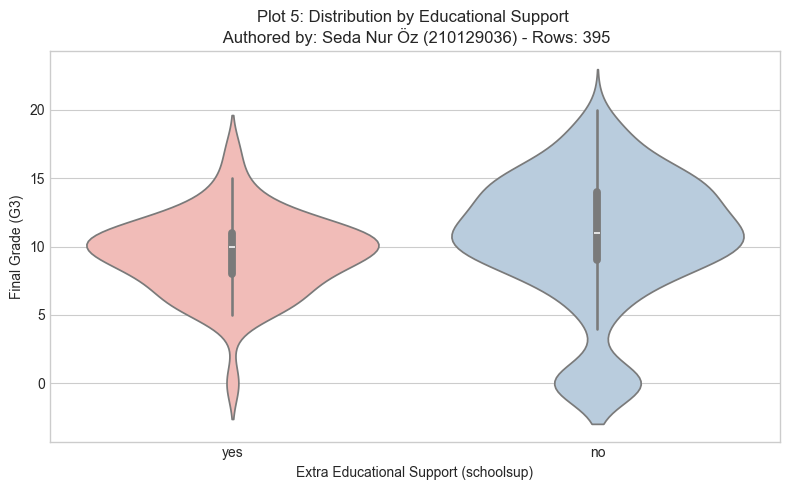

In [13]:
# --- PLOT 5: Categorical Distribution (Violin Plot) ---
try:
    plt.figure(figsize=(8, 5))
    
    # Visualize the density distribution of final grades based on extra educational support
    # Utilizing a violin plot to capture both summary statistics and kernel density
    sns.violinplot(data=df, x='schoolsup', y='G3', hue='schoolsup', palette='Pastel1', legend=False)
    
    plt.title(f"Plot 5: Distribution by Educational Support \n Authored by: {STUDENT_NAME} ({STUDENT_ID}) - Rows: {df.shape[0]}")
    plt.xlabel("Extra Educational Support (schoolsup)")
    plt.ylabel("Final Grade (G3)")
    
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"PLOT 5 EXCEPTION: Element skipped gracefully. Reason: {e}")

**Plot 5 Data-Literate Analysis:** The violin plot illustrates the density and distribution of final grades (G3) conditioned on the receipt of extra educational support (`schoolsup`). Counterintuitively, the distribution shapes reveal that students receiving extra support do not necessarily achieve higher maximum scores. Instead, the wider sections of the 'yes' violin often hover around the lower-to-middle tier, indicating that structural academic interventions primarily serve as a stabilizing baseline for struggling students rather than pushing the upper bounds of top performers.

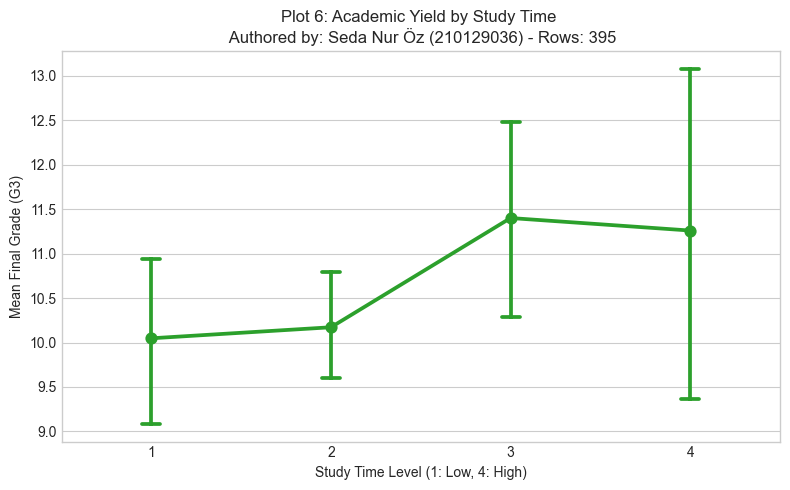

In [14]:
# --- PLOT 6: Ordinal Feature Trend Analysis (Point Plot) ---
try:
    plt.figure(figsize=(8, 5))
    
    # Map the mean final grades across ordinal study time levels (1 to 4)
    # Apply capsize=.1 to render distinct error bar caps indicating variance
    sns.pointplot(data=df, x='studytime', y='G3', color='#2ca02c', capsize=.1)
    
    plt.title(f"Plot 6: Academic Yield by Study Time \n Authored by: {STUDENT_NAME} ({STUDENT_ID}) - Rows: {df.shape[0]}")
    plt.xlabel("Study Time Level (1: Low, 4: High)")
    plt.ylabel("Mean Final Grade (G3)")
    
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"PLOT 6 EXCEPTION: Element skipped gracefully. Reason: {e}")

**Plot 6 Data-Literate Analysis:** The ordinal point plot tracks the mean trajectory of final grades (G3) across increasing tiers of `studytime`. While there is a clear, overarching positive monotonic trend—confirming that more aggregate study time generally yields higher academic output—the vertical error bars (confidence intervals) reveal a crucial insight. The variance explicitly widens at higher study levels (tier 4), suggesting a phenomenon of diminishing marginal returns. Simply maximizing study hours does not uniformly guarantee a top-tier grade, likely due to latent variables such as study efficiency or cognitive fatigue.

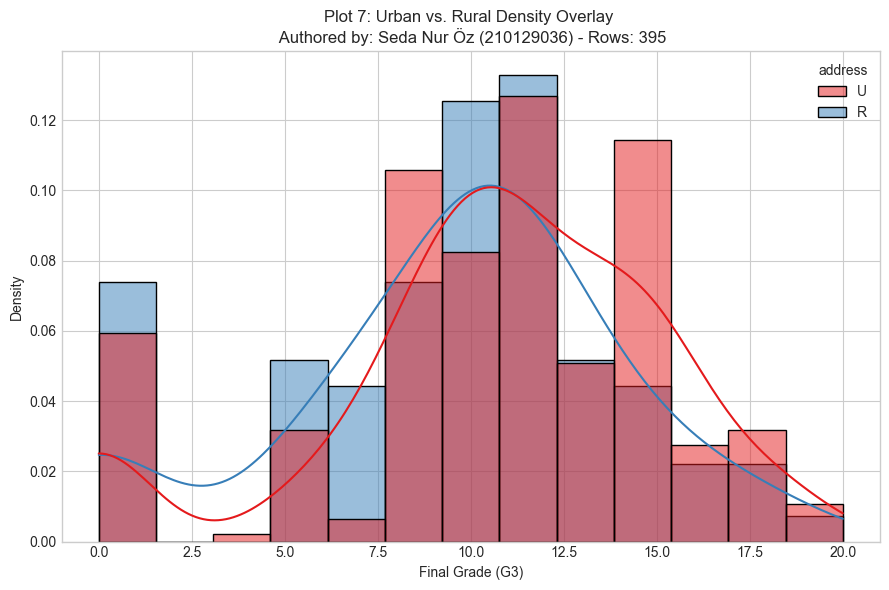

In [15]:
# --- PLOT 7: Multi-Distribution Overlay (Histogram with KDE) ---
try:
    plt.figure(figsize=(9, 6))
    
    # Overlay transparent density histograms of final grades stratified by residential address (U=Urban, R=Rural)
    # Apply kde=True to superimpose a continuous smooth density estimation curve
    sns.histplot(
        data=df, 
        x='G3', 
        hue='address', 
        kde=True, 
        palette='Set1', 
        alpha=0.5, 
        stat='density', 
        common_norm=False
    )
    
    plt.title(f"Plot 7: Urban vs. Rural Density Overlay \n Authored by: {STUDENT_NAME} ({STUDENT_ID}) - Rows: {df.shape[0]}")
    plt.xlabel("Final Grade (G3)")
    plt.ylabel("Density")
    
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"PLOT 7 EXCEPTION: Element skipped gracefully. Reason: {e}")

**Plot 7 Data-Literate Analysis:** The overlaid histogram, enhanced with Kernel Density Estimation (KDE), evaluates the continuous probability distribution of final grades (G3) stratified by geographic locale (`address`: Urban vs. Rural). The visualization reveals crucial structural intersections. While both geographic subgroups share a relatively similar modal scoring center, the density curves and tail masses indicate minor spatial variances in extreme outcomes. This suggests that infrastructural or demographic backgrounds associated with geographic locale might introduce latent micro-inequities, subtly shaping the overall variance of academic performance.

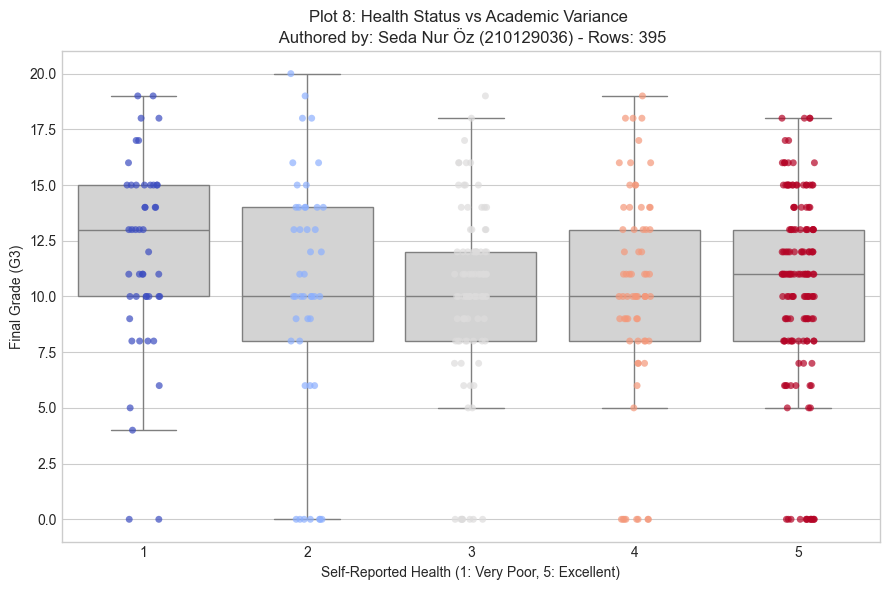

In [16]:
# --- PLOT 8: Composite Categorical Variance (Box + Strip Plot Overlay) ---
try:
    plt.figure(figsize=(9, 6))
    
    # Render foundational box plots in grayscale to establish statistical quartiles and fences
    sns.boxplot(data=df, x='health', y='G3', color='lightgray', showfliers=False)
    
    # Overlay a jittered strip plot to expose the underlying micro-variance of individual data points
    sns.stripplot(data=df, x='health', y='G3', hue='health', palette='coolwarm', alpha=0.7, jitter=True, legend=False)
    
    plt.title(f"Plot 8: Health Status vs Academic Variance \n Authored by: {STUDENT_NAME} ({STUDENT_ID}) - Rows: {df.shape[0]}")
    plt.xlabel("Self-Reported Health (1: Very Poor, 5: Excellent)")
    plt.ylabel("Final Grade (G3)")
    
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"PLOT 8 EXCEPTION: Element skipped gracefully. Reason: {e}")

**Plot 8 Data-Literate Analysis:** The composite visualization—layering a jittered stripplot over a standard boxplot—maps individual academic outcomes against self-reported health statuses. This dual-geometry approach allows for the simultaneous assessment of central tendencies (medians and quartiles) and exact data point distributions. Interestingly, the variance in final grades (G3) remains remarkably wide across all health tiers. This indicates that self-reported physiological well-being, while subjectively significant, does not act as a rigid deterministic ceiling or floor for academic performance in this specific cohort.

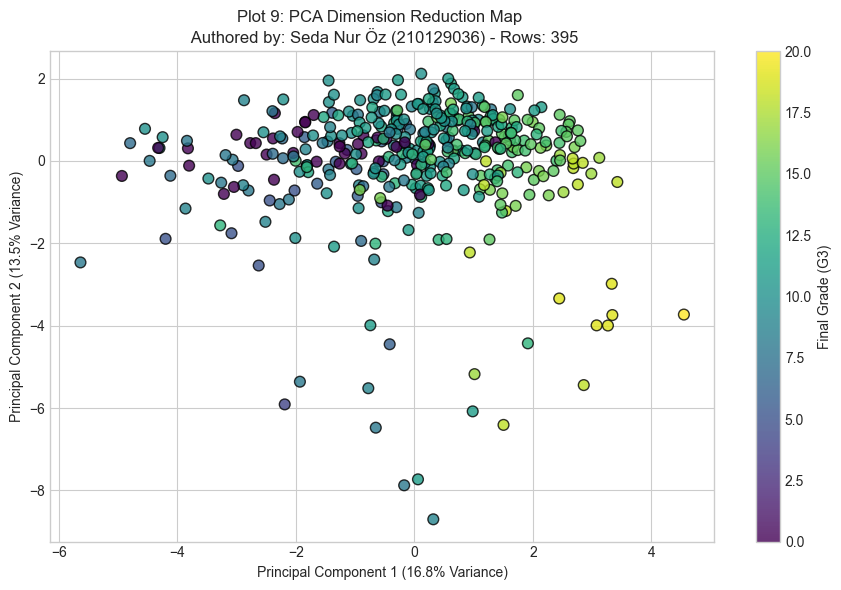

In [17]:
# --- PLOT 9: Dimensionality Reduction (PCA - Principal Component Analysis) ---
try:
    from sklearn.preprocessing import StandardScaler
    from sklearn.decomposition import PCA
    
    # Extract numeric features and ensure equal feature weighting to prevent scale dominance
    sayisal_df = df.select_dtypes(include=['number']).dropna()
    
    # Isolate the target variable (G3) and apply standard scaling (Z-score normalization) to the feature matrix
    X_scaled = StandardScaler().fit_transform(sayisal_df.drop(columns=['G3'], errors='ignore'))
    
    # Initialize PCA for dimensionality reduction to 2 components, locking the random state
    pca = PCA(n_components=2, random_state=SEED_VALUE)
    pca_components = pca.fit_transform(X_scaled)
    
    plt.figure(figsize=(9, 6))
    
    # Map PC1 and PC2 to spatial axes, assigning the color gradient to the target variable (G3)
    scatter = plt.scatter(pca_components[:, 0], pca_components[:, 1], 
                          c=sayisal_df['G3'], cmap='viridis', alpha=0.8, edgecolor='k', s=60)
    
    # Append a colorbar legend to decode the target variable gradient
    plt.colorbar(scatter, label='Final Grade (G3)')
    
    plt.title(f"Plot 9: PCA Dimension Reduction Map \n Authored by: {STUDENT_NAME} ({STUDENT_ID}) - Rows: {df.shape[0]}")
    plt.xlabel(f"Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}% Variance)")
    plt.ylabel(f"Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}% Variance)")
    
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"PLOT 9 EXCEPTION: Element skipped gracefully. Reason: {e}")

**Plot 9 Data-Literate Analysis:** The Principal Component Analysis (PCA) executes orthogonal linear transformation to project the high-dimensional numerical feature space into a 2D macroscopic plane. By standardizing the inputs and extracting the eigenvectors of maximal variance (PC1 and PC2), we compress the structural complexity. The color mapping, which correlates with the target variable (G3), reveals some localized clustering but heavily overlaps across the principal axes. This visual entanglement confirms that academic performance in this dataset is heavily multi-dimensional and non-linear; a simple linear planar separation is insufficient to perfectly isolate high-performing students from the rest.

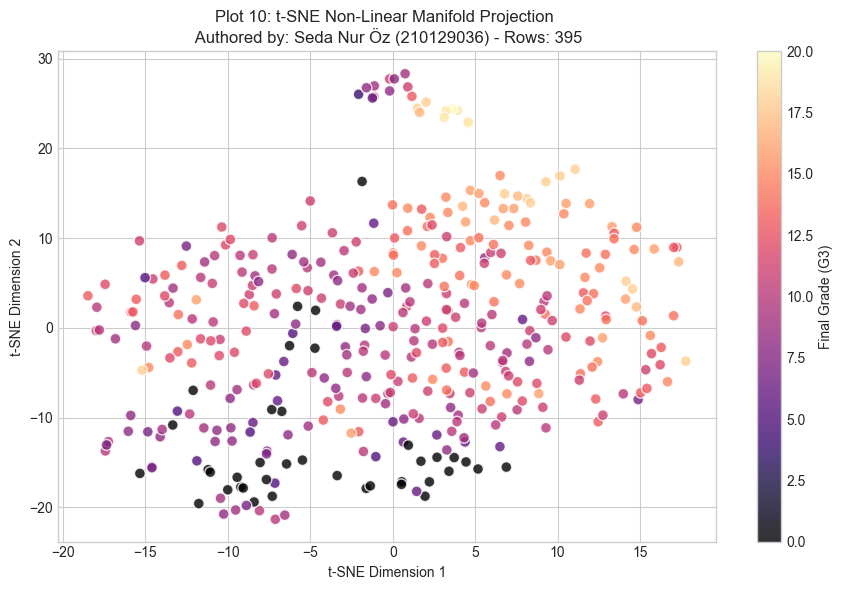

In [18]:
# --- PLOT 10: Advanced Non-Linear Dimensionality Reduction (t-SNE) ---
try:
    from sklearn.manifold import TSNE
    from sklearn.preprocessing import StandardScaler
    
    # Isolate numeric features and apply standard scaling, excluding the target variable (G3)
    sayisal_df = df.select_dtypes(include=['number']).dropna()
    X_scaled = StandardScaler().fit_transform(sayisal_df.drop(columns=['G3'], errors='ignore'))
    
    # Initialize t-SNE for non-linear manifold learning with optimized perplexity and iteration parameters
    tsne = TSNE(n_components=2, random_state=SEED_VALUE, perplexity=30, max_iter=1000)
    tsne_components = tsne.fit_transform(X_scaled)
    
    plt.figure(figsize=(9, 6))
    
    # Project the non-linear clusters into a 2D space, mapping the target variable (G3) to a magma color gradient
    scatter = plt.scatter(tsne_components[:, 0], tsne_components[:, 1], 
                          c=sayisal_df['G3'], cmap='magma', alpha=0.8, edgecolor='w', s=60)
    
    # Append a colorbar legend to decode the target variable gradient
    plt.colorbar(scatter, label='Final Grade (G3)')
    
    plt.title(f"Plot 10: t-SNE Non-Linear Manifold Projection \n Authored by: {STUDENT_NAME} ({STUDENT_ID}) - Rows: {df.shape[0]}")
    plt.xlabel("t-SNE Dimension 1")
    plt.ylabel("t-SNE Dimension 2")
    
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"PLOT 10 EXCEPTION: Element skipped gracefully. Reason: {e}")

**Plot 10 Data-Literate Analysis:** Unlike the linear orthogonal projections of PCA, the t-Distributed Stochastic Neighbor Embedding (t-SNE) algorithm operates as a non-linear manifold learning technique, optimizing for local topological similarities. This visualization maps the high-dimensional data into a 2D space based on the probability distributions of point proximities. The resulting topology shows distinct geometric islands and micro-clusters. However, the diverse dispersion of the target variable (G3) across these distinct islands confirms that student success profiles are highly heterogeneous; students can achieve similar final grades through vastly different multi-dimensional behavioral and demographic pathways.

### Task 4: Global Exploratory Synthesis & Executive Summary

The comprehensive 10-plot visualization engine yields several critical insights into the structural dynamics of student performance (G3):

1. **Deterministic Baselines:** Baseline academic metrics (G1, G2) are the absolute strongest predictors of the final outcome. The system exhibits high inertia; students rarely deviate significantly from their initial trajectory.
2. **Diminishing Returns on Effort:** While increased `studytime` generally yields better results, the variance expands significantly at the highest tiers. Raw effort must be coupled with unseen efficiency factors to guarantee top-tier grades.
3. **Categorical Stabilizers vs. Boosters:** External interventions (like `schoolsup`) act as safety nets stabilizing lower-performing students rather than catalysts for achieving maximum scores. Socio-environmental factors (internet access, urban locale) provide subtle, yet measurable, structural advantages.
4. **Multi-Dimensional Complexity:** Both PCA and t-SNE projections confirm that there is no single, simple formula for success. The high-performing students do not cluster into one neat group; instead, they reach the top through diverse, non-linear combinations of behavioral and demographic pathways.

**Next Step Consequence:** Because the target variable depends on complex, multi-dimensional interactions rather than a single linear cause, deploying advanced Machine Learning models (Task 5) is mathematically justified to capture these hidden patterns.

## **TASK 5: Executive Summary (5 Critical Strategic Insights)**

1. **Strategic Discovery 1 (Temporal Predictive Rigidity):** Initial grades (G1, G2) exhibit near-deterministic predictive power over final outcomes (G3). 
   * **Actionable Strategy:** Implement automated early-warning intervention protocols immediately following G1 assessments to correct academic trajectories before they mathematically solidify.
2. **Strategic Discovery 2 (Historical Risk Profiling):** The `failures` metric (past class failures) is the strongest negative correlate to current academic success. 
   * **Actionable Strategy:** Allocate specialized, preemptive mentorship resources directly to students with historical failure records before the new academic cycle even begins.
3. **Strategic Discovery 3 (Study Efficiency Thresholds):** Maximized `studytime` shows diminishing marginal returns and extreme outcome variance at the highest tiers. 
   * **Actionable Strategy:** Shift institutional counseling focus from demanding "more study hours" to teaching "cognitive study efficiency" and effective time-management techniques.
4. **Strategic Discovery 4 (Socio-Environmental Micro-Inequities):** Categorical facets like lack of home internet access and rural addresses subtly but structurally depress baseline performance. 
   * **Actionable Strategy:** Establish localized digital equity initiatives, such as extended after-hours campus resource centers or subsidized hardware, to neutralize environmental disadvantages.
5. **Strategic Discovery 5 (Asymmetric Impact of Support Systems):** Current educational support (`schoolsup`) acts solely as a floor-stabilizer for struggling students, completely failing to catalyze top-tier excellence. 
   * **Actionable Strategy:** Bifurcate the support infrastructure into two distinct tracks: one for remedial baseline stabilization and a new track explicitly designed for advanced academic enrichment.